Fashion-MNIST Dataset :
Fashion MNIST dataset consists of 70k images(60k-> Training set , 10k->testing set) . There are 10 different class of images - Classes:['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'].
The images are of the sizw 28x28 pixel and are greyscale images.
Our goal is to build a CNN image classification model to be able to correctly classify the images.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

import torch
import torch.nn as nn
from torch.nn.modules.activation import ReLU
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

#_--Reproducibility---
SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed(SEED)
  torch.cuda.manual_seed_all(SEED)

In [ ]:
# Download the dataset
train_dataset=datasets.FashionMNIST(root='./data',train=True,download=True,transform=None)
test_dataset=datasets.FashionMNIST(root='./data',train=False,download=True,transform=None)

Training sample:60000
Testing sample:10000
Classes:['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
<class 'PIL.Image.Image'>
9


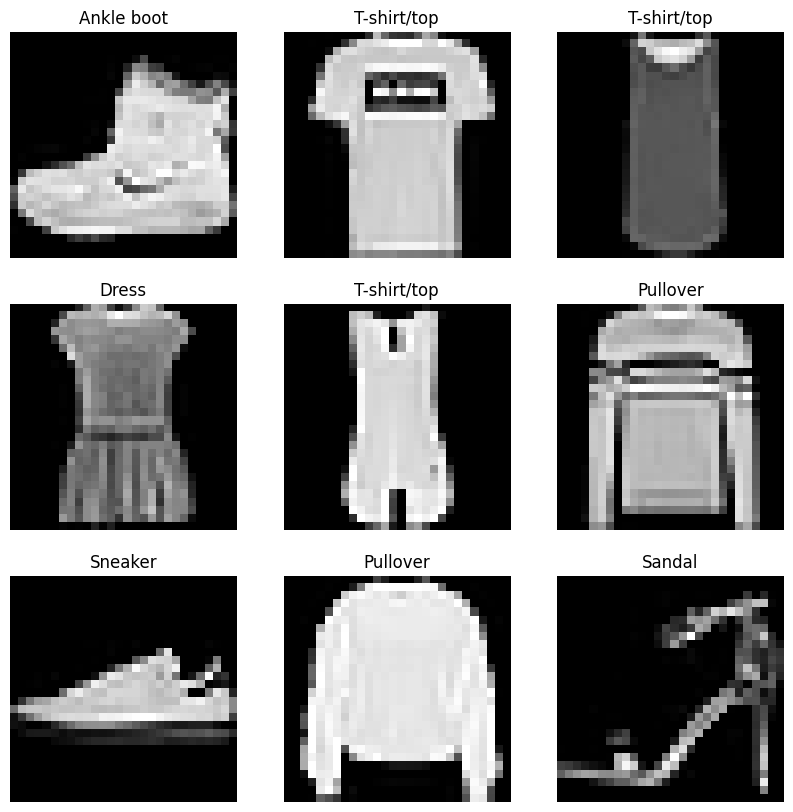

T-shirt/top:6000
Trouser:6000
Pullover:6000
Dress:6000
Coat:6000
Sandal:6000
Shirt:6000
Sneaker:6000
Bag:6000
Ankle boot:6000


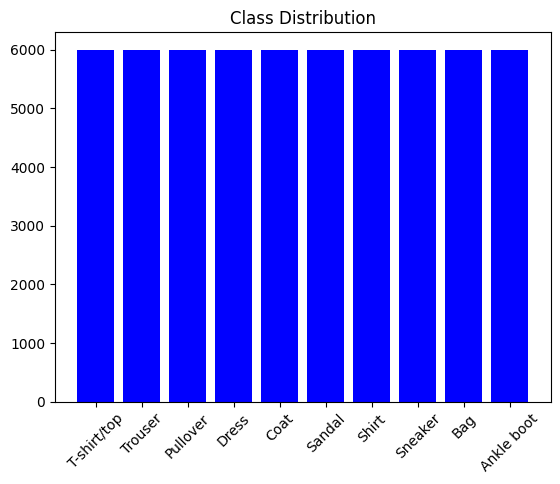

In [ ]:
# Exploring the Dataset
print(f'Training sample:{len(train_dataset)}')
print(f'Testing sample:{len(test_dataset)}')

print(f'Classes:{train_dataset.classes}')
images,labels=train_dataset[0]
print(type(images))
print(labels)

#Visualize few images from the dataset
plt.figure(figsize=(10,10))
for i in range(9):
  images,labels=train_dataset[i]
  plt.subplot(3,3,i+1)
  plt.imshow(images,cmap='gray')
  plt.title(train_dataset.classes[labels])
  plt.axis('off')

plt.show()

# Now we need to check the class distribution . Do we have any imbalance in our class distribution ?
from collections import Counter
label_list=[labels for _,labels in train_dataset]
count=Counter(label_list)

for k,v in sorted(count.items()):
  print(f'{train_dataset.classes[k]}:{v}')
  plt.bar(train_dataset.classes[k],v,color='blue')
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

Mean:0.2860,STD:0.3530


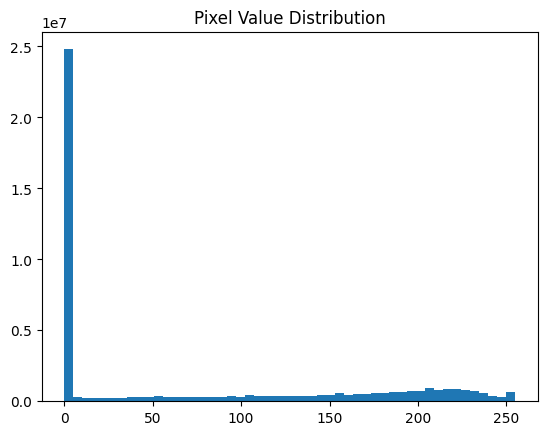

In [ ]:
#pixel distribution
import numpy as np

all_pixels=np.concatenate([
    np.array(images).flatten() for images,_ in train_dataset
])

mean=np.mean((all_pixels/255.0))
std=np.std(all_pixels/255.0)   # getting the mean and std to use it for normalization
print(f'Mean:{mean:.4f},STD:{std:.4f}')
plt.hist(all_pixels, bins=50)
plt.title("Pixel Value Distribution")
plt.show()

In [ ]:
# Now we will transform and normalize our dataset
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
])
train_dataset_tf=datasets.FashionMNIST(root='./data',train=True,download=False,transform=transform)
test_dataset_tf=datasets.FashionMNIST(root='./data',train=False,download=False,transform=transform)

#DataLoaders
train_loader=DataLoader(train_dataset_tf,batch_size=64,shuffle=True)
test_loader=DataLoader(test_dataset_tf,batch_size=64,shuffle=False)

In [ ]:
# CNN Model Building
class CNN(nn.Module):
  def __init__(self):
    super(CNN,self).__init__()

  #feature extractor
    self.features=nn.Sequential(
        nn.Conv2d(1,32,kernel_size=3,padding=1),   #(32,28,28)
        nn.ReLU(),
        nn.MaxPool2d(2,2),                     #(32,14,14)

        nn.Conv2d(32,64,kernel_size=3,padding=1),   #(64,14,14)
        nn.ReLU(),
        nn.MaxPool2d(2,2),                        #(64,7,7)
  )

 #classifier head
    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7,128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128,10),

 )
#forward pass
  def forward(self,x):
    x=self.features(x)
    x=self.classifier(x)
    return x

In [ ]:
#SETUP
device=torch.device('cuda'if torch.cuda.is_available() else 'cpu')
model=CNN().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [ ]:
#Train the Model
def train(model,loader,criterion,optimizer,device):
  model.train()
  total_loss,correct= 0,0

  for images,labels in loader:
    images,labels=images.to(device),labels.to(device)
    optimizer.zero_grad()
    output=model(images)
    loss=criterion(output,labels)
    loss.backward()
    optimizer.step()

    total_loss +=loss.item()
    correct +=(output.argmax(1)==labels).sum().item()

  avg_loss=total_loss/len(loader)
  accuracy=100*correct/len(loader.dataset)
  return avg_loss,accuracy

In [ ]:
#Evaluate the Model
def eval(model,loader,criterion,device):
  model.eval()
  total_loss,correct=0,0
  all_preds,all_labels=[],[]
  with torch.no_grad():
    for images,labels in loader:
      images,labels=images.to(device),labels.to(device)
      output=model(images)
      loss=criterion(output,labels)
      total_loss +=loss.item()
      correct +=(output.argmax(1)==labels).sum().item()
      #store labels and predictions
      preds=output.argmax(1)
      all_preds.extend(preds.cpu().numpy())   # numpy works on CPU ,preds.cpu-> moves tensors from GPUU->CPU
      all_labels.extend(labels.cpu().numpy())

  avg_loss=total_loss/len(loader)
  accuracy=100*correct/len(loader.dataset)
  return avg_loss,accuracy,all_preds,all_labels

In [ ]:
#Run your model
for epoch in range(1,6):
  train_loss,train_acc=train(model,train_loader,criterion,optimizer,device)
  test_loss,test_acc,all_labels,all_preds=eval(model,test_loader,criterion,device)
  print(f'Epoch {epoch} | Train {train_acc:.1f}%| Test {test_acc:.1f}%')

Epoch 1 | Train 81.0%| Test 87.8%
Epoch 2 | Train 87.4%| Test 88.8%
Epoch 3 | Train 89.2%| Test 90.5%
Epoch 4 | Train 90.2%| Test 91.1%
Epoch 5 | Train 91.3%| Test 91.2%


Final Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1023
           1       0.98      0.99      0.99       989
           2       0.89      0.85      0.87      1052
           3       0.92      0.89      0.90      1038
           4       0.80      0.91      0.85       886
           5       0.98      0.99      0.98       989
           6       0.75      0.75      0.75      1000
           7       0.98      0.94      0.96      1043
           8       0.99      0.98      0.98      1010
           9       0.95      0.98      0.97       970

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



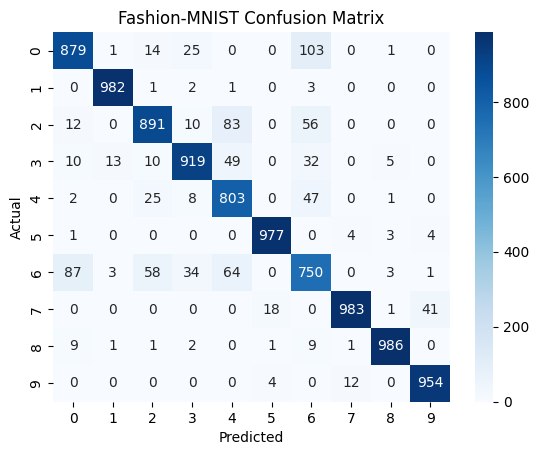

In [67]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print('Final Classification Report:')
print(classification_report(all_labels, all_preds))
cm=confusion_matrix(all_labels, all_preds)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fashion-MNIST Confusion Matrix")
plt.show()